In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/train_prepared.csv")
print(df.shape)

Matplotlib is building the font cache; this may take a moment.


(1290081, 12)


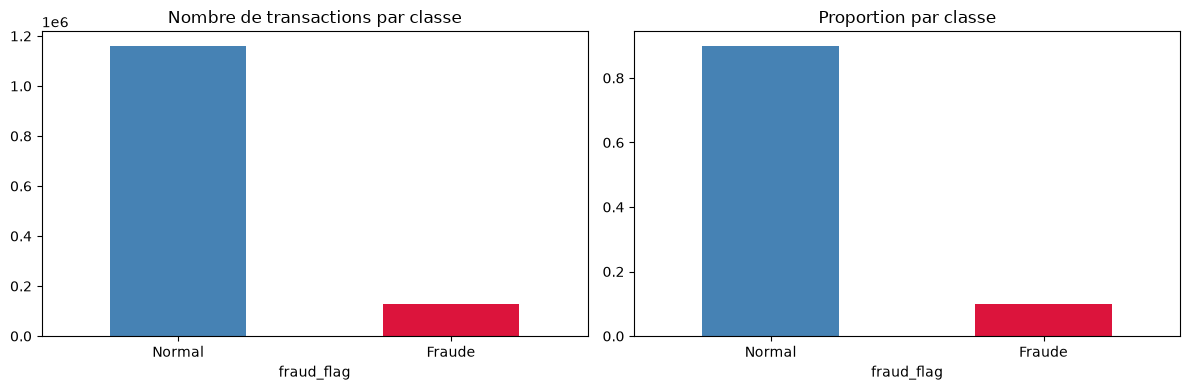

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['fraud_flag'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Nombre de transactions par classe')
axes[0].set_xticklabels(['Normal', 'Fraude'], rotation=0)

df['fraud_flag'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'])
axes[1].set_title('Proportion par classe')
axes[1].set_xticklabels(['Normal', 'Fraude'], rotation=0)

plt.tight_layout()
plt.show()

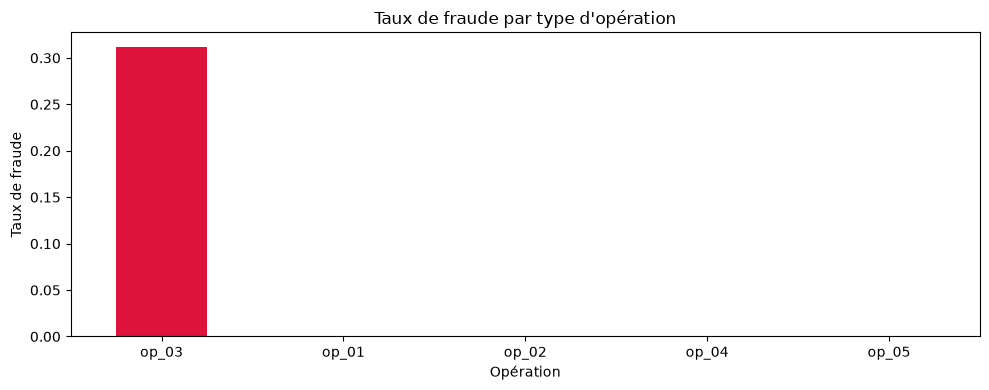

operation
op_03    0.311907
op_01    0.000000
op_02    0.000000
op_04    0.000000
op_05    0.000000
Name: fraud_flag, dtype: float64


In [3]:
fraud_by_op = df.groupby('operation')['fraud_flag'].mean().sort_values(ascending=False)

fraud_by_op.plot(kind='bar', figsize=(10, 4), color='crimson')
plt.title('Taux de fraude par type d\'opération')
plt.ylabel('Taux de fraude')
plt.xlabel('Opération')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(fraud_by_op)

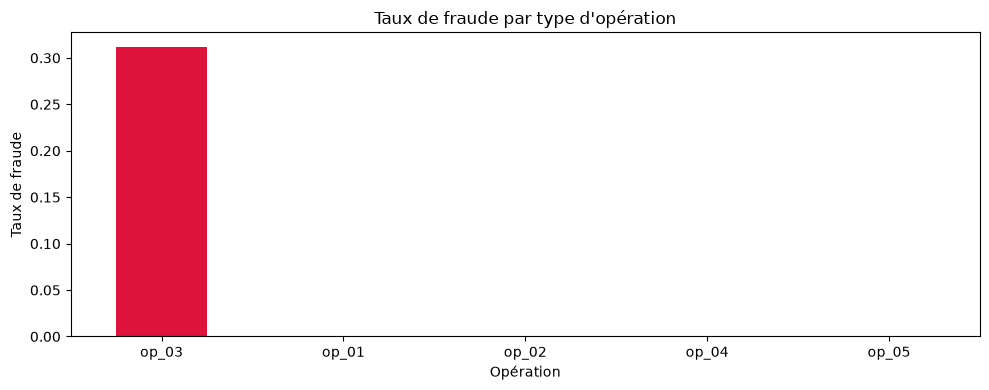

operation
op_03    0.311907
op_01    0.000000
op_02    0.000000
op_04    0.000000
op_05    0.000000
Name: fraud_flag, dtype: float64


In [4]:
fraud_by_op = df.groupby('operation')['fraud_flag'].mean().sort_values(ascending=False)

fraud_by_op.plot(kind='bar', figsize=(10, 4), color='crimson')
plt.title('Taux de fraude par type d\'opération')
plt.ylabel('Taux de fraude')
plt.xlabel('Opération')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(fraud_by_op)

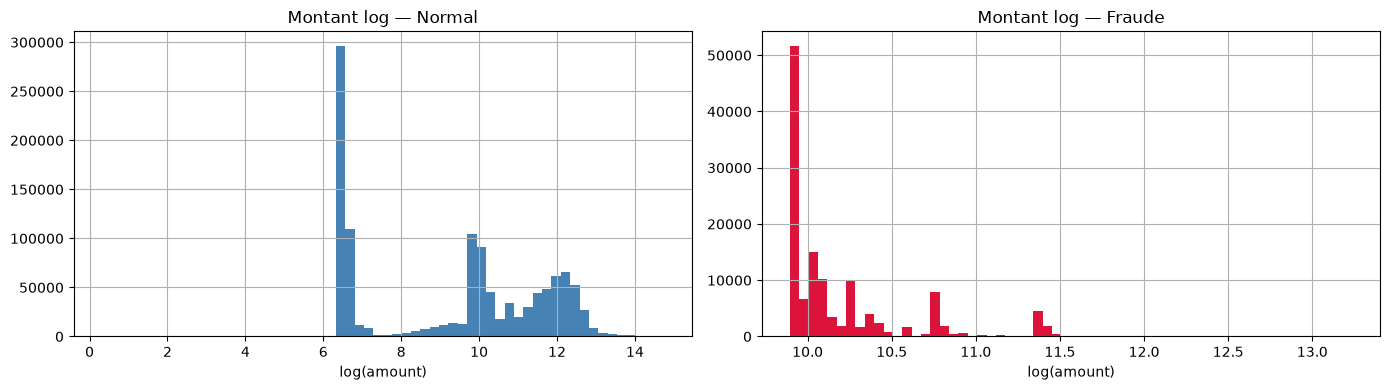

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['fraud_flag'] == 0]['amount'].apply(np.log1p).hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Montant log — Normal')
axes[0].set_xlabel('log(amount)')

df[df['fraud_flag'] == 1]['amount'].apply(np.log1p).hist(bins=60, ax=axes[1], color='crimson')
axes[1].set_title('Montant log — Fraude')
axes[1].set_xlabel('log(amount)')

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

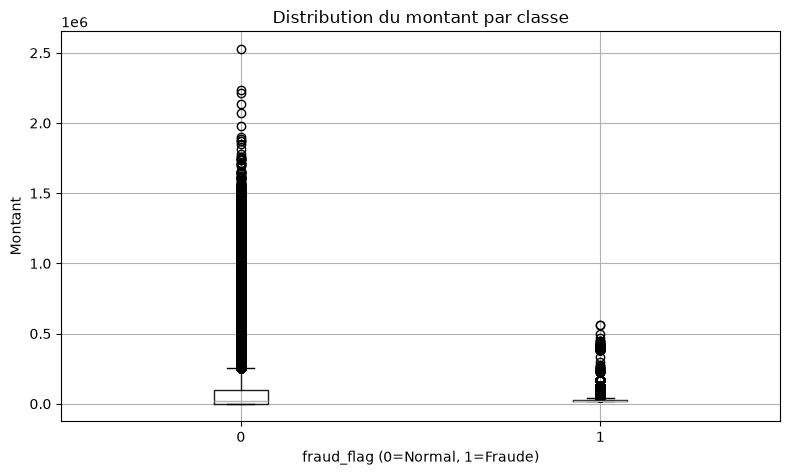

In [6]:
plt.figure(figsize=(8, 5))
df.boxplot(column='amount', by='fraud_flag', figsize=(8, 5))
plt.title('Distribution du montant par classe')
plt.suptitle('')
plt.xlabel('fraud_flag (0=Normal, 1=Fraude)')
plt.ylabel('Montant')
plt.tight_layout()
plt.show()

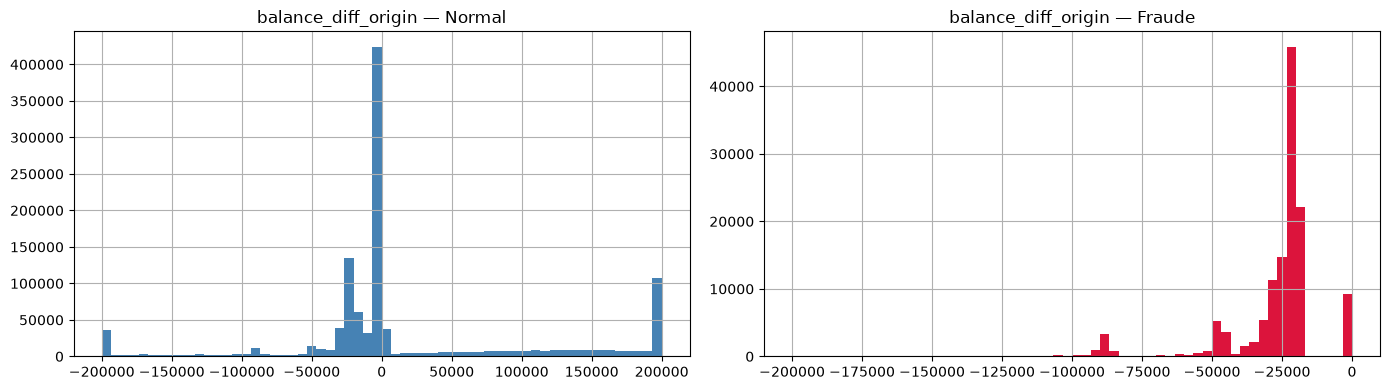

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['fraud_flag'] == 0]['balance_diff_origin'].clip(-200000, 200000).hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('balance_diff_origin — Normal')

df[df['fraud_flag'] == 1]['balance_diff_origin'].clip(-200000, 200000).hist(bins=60, ax=axes[1], color='crimson')
axes[1].set_title('balance_diff_origin — Fraude')

plt.tight_layout()
plt.show()

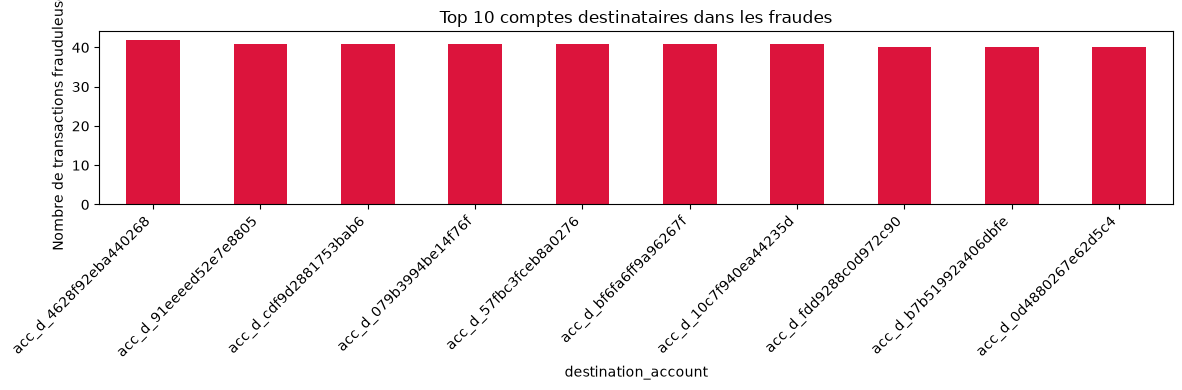

In [8]:
top_dest = (
    df[df['fraud_flag'] == 1]
    .groupby('destination_account')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_dest.plot(kind='bar', figsize=(12, 4), color='crimson')
plt.title('Top 10 comptes destinataires dans les fraudes')
plt.ylabel('Nombre de transactions frauduleuses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

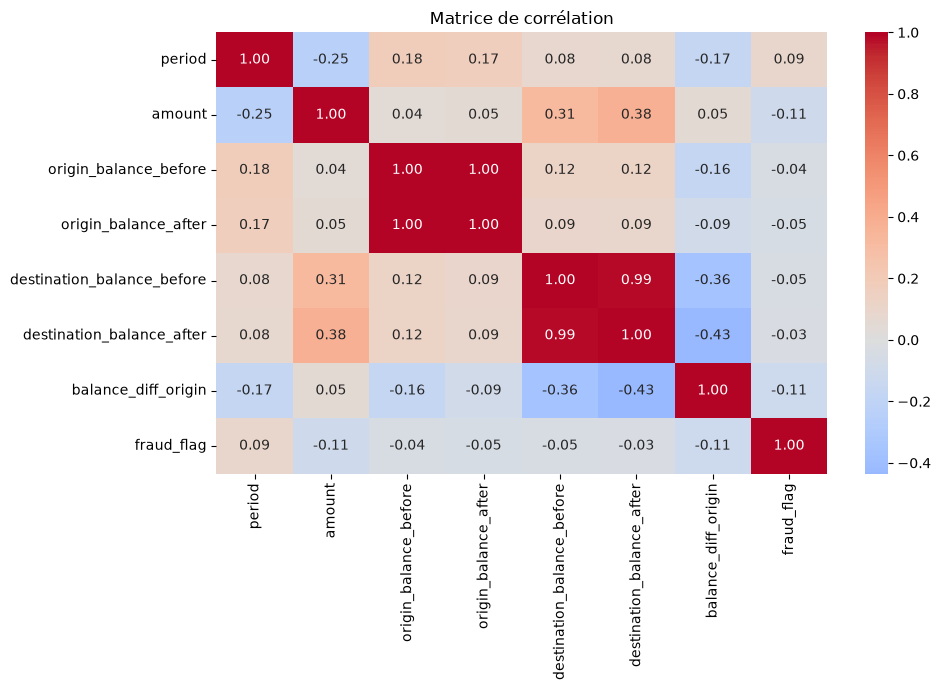

In [9]:
num_cols = ['period', 'amount', 'origin_balance_before', 'origin_balance_after',
            'destination_balance_before', 'destination_balance_after',
            'balance_diff_origin', 'fraud_flag']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()